**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)

# 1. Linear economy: the restricted recursive SVAR(2)

The paper's linear environment: a recursive SVAR(2) in the output gap, inflation and the policy rate,
estimated on 1987Q3-2007Q2 and restricted by dropping statistically weak second lags (Hinterlang &
Tänzer, 2021, Section 2.1.1 and Table 9).

**Inputs:** `artifacts/data/` (notebook `00_data`).
**Outputs:** `artifacts/linear/svar_restricted.json` (the economy later notebooks simulate) and
`artifacts/linear/one_step_fixed.csv` (its one-step fits).

In [1]:
import numpy as np
import pandas as pd
from cultivars.multivariate import VAR, RecursiveSVAR
from IPython.display import Markdown, display

import autofed as af
from autofed import linear as lin
from autofed import plots

nb = af.NotebookSession(
    "01_linear_svar", number=1, title="Linear economy: the restricted recursive SVAR(2)"
)
panel = af.load_macro_panel(nb.artifacts("data"))
cfg = panel.config
NAMES = list(af.NAMES)  # recursive ordering: y -> pi -> i
SHORT = {"y": "Output gap", "pi": "Inflation", "i": "Policy rate"}
df_train, df_all = panel.train, panel.full
print(
    f"Data vintage {panel.retrieved} | training {df_train.index[0]}-{df_train.index[-1]} | "
    f"full {df_all.index[0]}-{df_all.index[-1]}"
)

Data vintage 2026-10-07 | training 1987Q3-2007Q2 | full 1987Q3-2026Q2


# Baseline Specification (Bundesbank-aligned)

The baseline model estimates a **linear reduced-form macroeconomic environment** using a **recursive
(triangular) SVAR(2)** in the output gap $y_t$, inflation $\pi_t$ and the policy rate $i_t$, followed by
**post-estimation lag restriction** based on statistical significance. The resulting system is used as a
compact forecasting and simulation environment for downstream policy-learning exercises (Sims, 1980;
Lütkepohl, 2005; Hinterlang & Tänzer, 2021).

## Estimating the linear environment (restricted recursive SVAR(2))

We estimate a **recursive reduced-form SVAR(2)**. The recursive structure is implemented by allowing
inflation to depend contemporaneously on the output gap (triangular ordering), which corresponds to a
standard Cholesky-style identification in VAR applications (Sims, 1980; Lütkepohl, 2005).

The paper writes the system in **structural form**, with contemporaneous $y_t$ in the inflation equation:

$$
y_t = C^y + a^{y\prime} s_t + \varepsilon^y_t,\qquad
\pi_t = C^\pi + a^\pi_{y,0}\,y_t + a^{\pi\prime} s_t + \varepsilon^\pi_t,\qquad
s_t = (y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2}).
$$

`cultivars` estimates the **reduced form** with `VAR` and identifies the recursive structure with
`RecursiveSVAR`; the two representations are linked exactly by the Cholesky factor $B$ of the residual
covariance:

$$
a^\pi_{y,0} = B_{\pi y} / B_{yy},\qquad
a^\pi_{\cdot} = \tilde a^\pi_{\cdot} - a^\pi_{y,0}\,\tilde a^y_{\cdot},
$$

where $\tilde a$ are reduced-form coefficients. The output-gap equation is identical in both forms because
$y$ is ordered first. Estimating the reduced form by multivariate least squares and applying the
triangular factor is numerically identical to the paper's equation-by-equation OLS on the structural
form; the notebook verifies that identity below before applying the lag restriction.

### Lag order
The paper fixes the lag order at $p = 2$. `cultivars` reports the information-criterion sweep on the
training sample as a check that this choice is defensible rather than assumed.

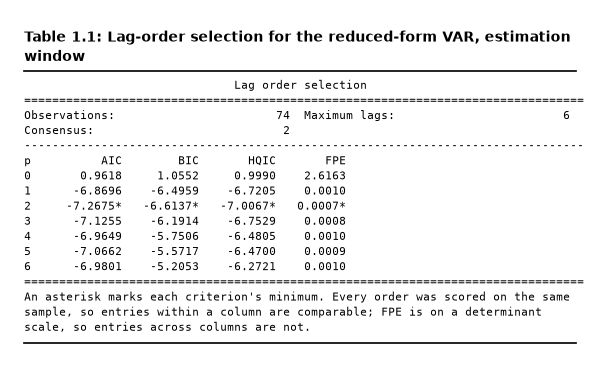

In [2]:
lag_selection = VAR(
    df_train[NAMES].to_numpy(), order=2, trend="c", names=NAMES
).lag_order_selection(max_lags=6)
nb.listing(
    str(lag_selection.to_table()),
    "lag_order_selection",
    "Lag-order selection for the reduced-form VAR, estimation window",
)

### Reduced-form VAR(2) and recursive identification
The reduced form is estimated on the training window and the recursive ordering $y \to \pi \to i$ is
declared explicitly through `RecursiveSVAR`. The `cultivars` summaries report the reduced-form
coefficients with standard errors and p-values, the stability of the companion matrix, and the impact
matrix implied by the ordering.

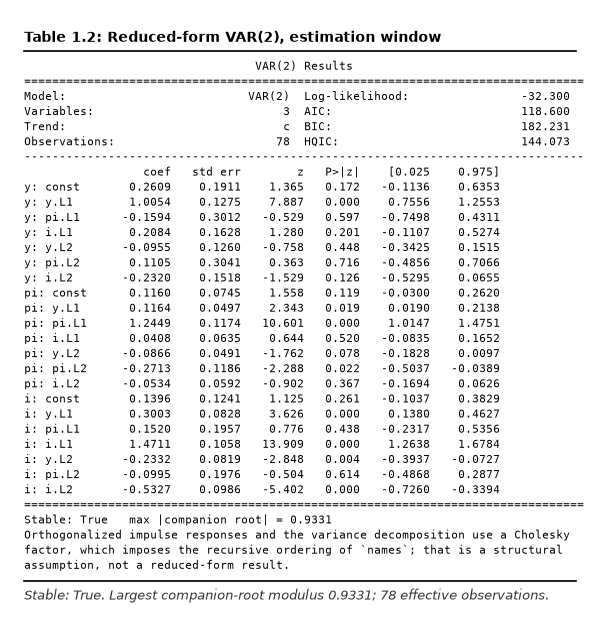

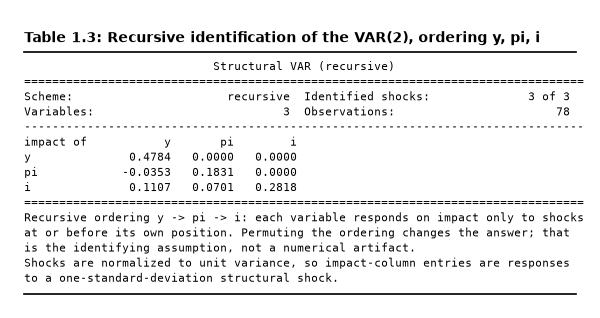

In [3]:
# Reduced-form VAR(2) on the estimation window, recursive identification y -> pi -> i
var = VAR(df_train[NAMES].to_numpy(), order=2, trend="c", names=NAMES).fit()
svar = RecursiveSVAR(var, order=NAMES).identify()
stability = var.stability_check()

nb.listing(
    str(var.summary()),
    "var_summary",
    "Reduced-form VAR(2), estimation window",
    note=(
        f"Stable: {var.is_stable}. Largest companion-root modulus"
        f" {float(stability.max_modulus):.4f}; {var.nobs} effective observations."
    ),
)
nb.listing(
    str(svar.summary()),
    "svar_summary",
    "Recursive identification of the VAR(2), ordering y, pi, i",
)

### Estimation outputs
For transparency and reproducibility, the equation-level estimation routine returns:
- fitted OLS objects (full and restricted) for each structural equation,
- the design matrices used for prediction,
- residual series for diagnostics,
- coefficient and p-value tables that remain index-stable even after restrictions.

This design supports clean table construction and avoids downstream errors when terms are excluded
during restriction. The helpers below are deliberately small: the restricted refit is ordinary least
squares with named columns dropped, and the Durbin–Watson and Breusch–Godfrey statistics follow the
`statsmodels` conventions used in the original notebook (Seabold & Perktold, 2010).

### Structural form from the reduced form (cross-check)
The helper below converts the `cultivars` reduced-form estimates and the Cholesky impact matrix into the
paper's structural notation. The result is compared with equation-by-equation OLS on the structural
design matrices: the two must agree to machine precision, which confirms that the `cultivars`
identification reproduces the paper's estimator exactly on the unrestricted system.

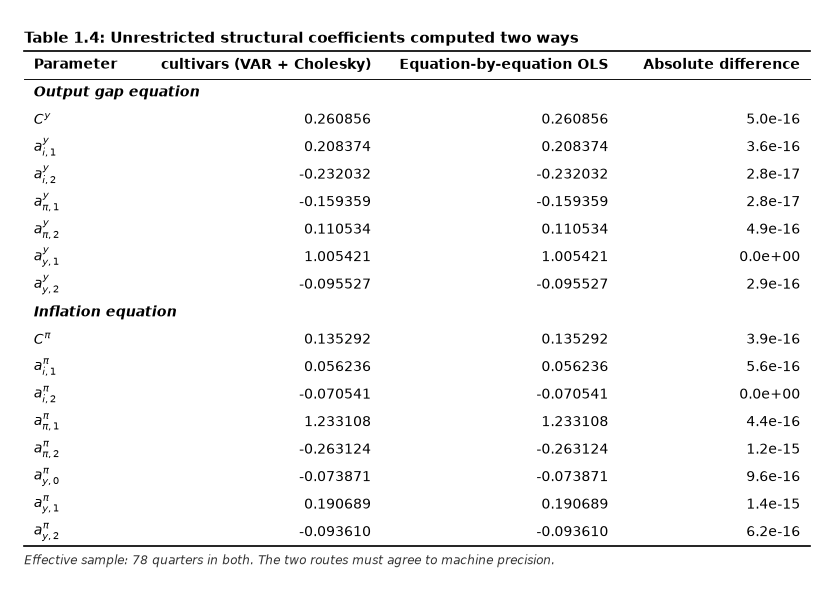

In [4]:
ALPHA_DROP = 0.10
svar_fit = lin.fit_linear_svar(df_train, alpha_drop=ALPHA_DROP)
struct = lin.structural_equations(var, svar)

blocks = {}
for eq, title, full in (
    ("y", "Output gap equation", svar_fit.full_y),
    ("pi", "Inflation equation", svar_fit.full_pi),
):
    block = pd.DataFrame({
        "cultivars (VAR + Cholesky)": pd.Series(struct[eq]),
        "Equation-by-equation OLS": full.params,
    })
    block.index = [lin.PARAMETER_TEX[eq][name] for name in block.index]
    blocks[title] = block
check = pd.concat(blocks, names=["Equation", "Parameter"])
check["Absolute difference"] = (check.iloc[:, 0] - check.iloc[:, 1]).abs()
assert np.allclose(
    check.iloc[:, 0], check.iloc[:, 1], atol=1e-8
), "structural mapping and OLS disagree"

nb.table(
    check,
    "structural_crosscheck",
    "Unrestricted structural coefficients computed two ways",
    float_format="{:.6f}",
    formats={"Absolute difference": "{:.1e}"},
    note=(
        f"Effective sample: {var.nobs} quarters in both. The two routes must agree to machine"
        " precision."
    ),
)

### Restriction rule (post-estimation lag selection)
Following the baseline approach, the SVAR(2) is first estimated in full and then **restricted by
removing statistically weak second-lag terms** using a significance threshold (default $\alpha = 0.10$)
applied to the full-model p-values of each structural equation. This yields a more parsimonious linear
environment while retaining the SVAR(2) starting point as the reference specification (Hinterlang &
Tänzer, 2021). No VAR estimator can express equation-specific zero restrictions, so the refit is an
explicit OLS step on the structural design matrices.

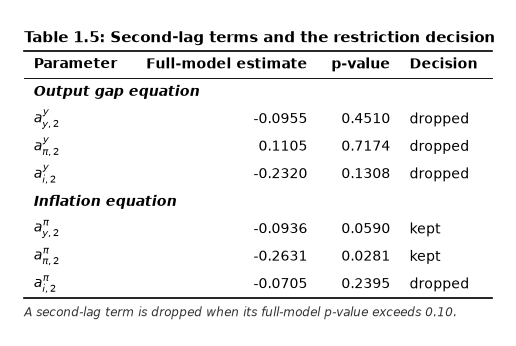

In [5]:
decisions = {}
for eq, title, full, dropped in (
    ("y", "Output gap equation", svar_fit.full_y, svar_fit.zeroed_y),
    ("pi", "Inflation equation", svar_fit.full_pi, svar_fit.zeroed_pi),
):
    for name in full.params.index:
        if name.endswith("_lag2"):
            decisions[(title, lin.PARAMETER_TEX[eq][name])] = {
                "Full-model estimate": float(full.params[name]),
                "p-value": float(full.pvalues[name]),
                "Decision": "dropped" if name in dropped else "kept",
            }
decisions = pd.DataFrame.from_dict(decisions, orient="index")
decisions.index = pd.MultiIndex.from_tuples(decisions.index, names=["Equation", "Parameter"])
nb.table(
    decisions,
    "lag_restriction",
    "Second-lag terms and the restriction decision",
    float_format="{:.4f}",
    note=f"A second-lag term is dropped when its full-model p-value exceeds {ALPHA_DROP:.2f}.",
)

### Estimation procedure

Let the state vector contain the output gap $y_t$, inflation $\pi_t$, and policy rate $i_t$. The linear
environment is estimated as a pair of reduced-form equations with up to two lags.

1. **Output-gap equation (no contemporaneous regressors)**
$$
y_t = C^y + \alpha^{y\prime} s_t^y + \varepsilon_t^y, \quad
s_t^y = (y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2}).
$$

2. **Inflation equation (recursive ordering allows contemporaneous $y_t$)**
$$
\pi_t = C^\pi + \alpha^{\pi\prime} s_t^\pi + \varepsilon_t^\pi, \quad
s_t^\pi = (y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2}).
$$

Both equations are first estimated via OLS (numerically identical to the `cultivars` reduced form plus
Cholesky identification, as verified above), and the model is then **restricted** by dropping
insignificant second-lag regressors based on the full-model p-values. This is a pragmatic, transparent
approach to obtain a compact environment suitable for simulation and comparison (Sims, 1980; Hinterlang
& Tänzer, 2021; Lütkepohl, 2005).

### Restricted reduced-form representation

After applying the lag restriction rule, the environment can be written as:
- a restricted output-gap equation with a subset of lag terms retained, and
- a restricted inflation equation that may include contemporaneous $y_t$ under the recursive ordering.

This representation is interpreted as a **reduced-form forecasting system**, not a fully structural causal
model (Sims, 1980; Lütkepohl, 2005).

### Linear environment mapping
The restricted SVAR defines a mapping from observed state variables and lags to one-step-ahead fitted
values:
$$
\hat f^m(s_t^m) = C^m + \alpha^{m\prime}s_t^m,\quad m\in\{\pi,y\}.
$$
This serves as the notebook's **linear economy environment** used for in-sample diagnostics and
out-of-sample comparison (Hinterlang & Tänzer, 2021).

### Substituted system

The restricted equations with their estimated coefficients:

In [6]:
display(Markdown(lin.equation_tex("y_t", svar_fit.coef("y"))))
display(Markdown(lin.equation_tex(r"\pi_t", svar_fit.coef("pi"))))

$$y_t = 0.3070 + 0.9775y_{t-1} - 0.0228\pi_{t-1} - 0.0499i_{t-1}$$

$$\pi_t = 0.1275 - 0.0642y_t + 0.2086y_{t-1} - 0.1094y_{t-2} + 1.2914\pi_{t-1} - 0.3150\pi_{t-2} - 0.0169i_{t-1}$$

### Restricted SVAR estimates and diagnostics

The table reports the restricted OLS coefficients and p-values with the residual diagnostics of the
paper's Table 9 (adjusted $\bar R^2$, MSE, the residual variance estimate, Durbin-Watson, and the
Breusch-Godfrey LM(1) statistic with its $\chi^2(1)$ p-value). The last column repeats the published
estimates. Differences reflect the data vintage, and they extend to the restriction itself: a term the
current vintage drops but the paper keeps shows a published value and no estimate.

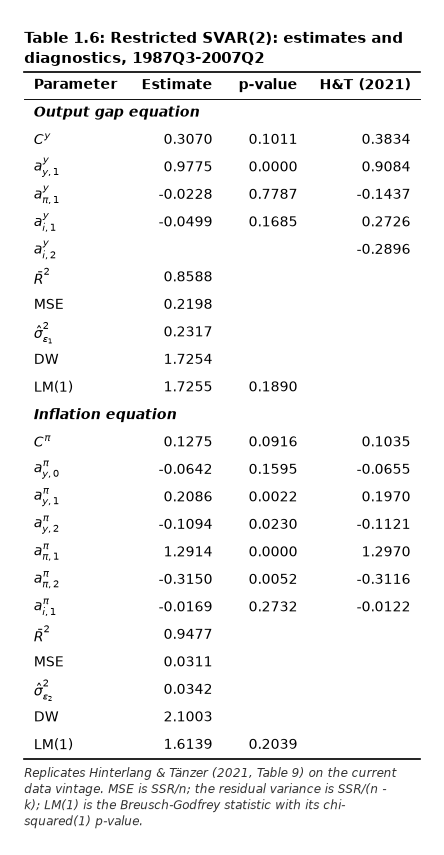

In [7]:
nb.table(
    lin.table_nine(svar_fit),
    "restricted_svar_estimates",
    f"Restricted SVAR(2): estimates and diagnostics, {cfg.train_start}-{cfg.train_end}",
    float_format="{:.4f}",
    note=(
        "Replicates Hinterlang & Tänzer (2021, Table 9) on the current data vintage. MSE is"
        " SSR/n; the residual variance is SSR/(n - k); LM(1) is the Breusch-Godfrey statistic"
        " with its chi-squared(1) p-value."
    ),
)

### System residual diagnostics (`cultivars`)
The estimates table above reports single-equation serial-correlation statistics, as the paper does. `cultivars` adds the
system-level view on the unrestricted VAR(2): a multivariate portmanteau test on the residual
autocorrelations, Jarque–Bera normality per equation, and an ARCH-LM test per equation. A rejected
portmanteau would indicate that two lags leave dependence in the residuals; ARCH effects would motivate
the stochastic-volatility model of the final section.

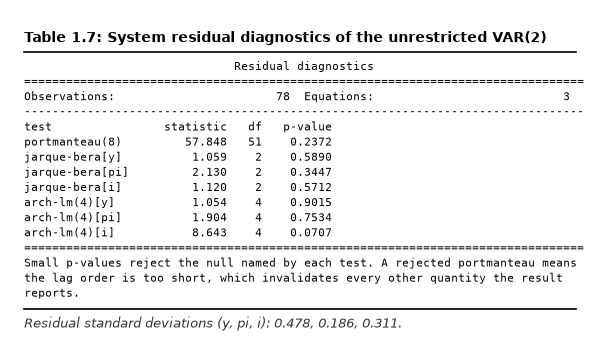

In [8]:
nb.listing(
    str(var.residual_diagnostics(portmanteau_lags=8, arch_lags=4)),
    "residual_diagnostics",
    "System residual diagnostics of the unrestricted VAR(2)",
    note="Residual standard deviations (y, pi, i): "
    + ", ".join(f"{v:.3f}" for v in np.sqrt(np.diag(var.sigma_u)))
    + ".",
)

### Impulse responses of the environment
A policy-learning agent acts through $i_t$; the recursive SVAR says how the environment answers. The
grid below shows the responses of every variable to a one-standard-deviation structural shock in every
variable under the ordering $y \to \pi \to i$: the policy rate reacts to output and prices within the
quarter, while output and prices react to the rate with a lag. That is the identifying assumption, stated
as such in the `RecursiveSVAR` summary. The forecast-error variance decomposition quantifies how much of
the variation in the output gap and inflation the model attributes to policy-rate shocks.

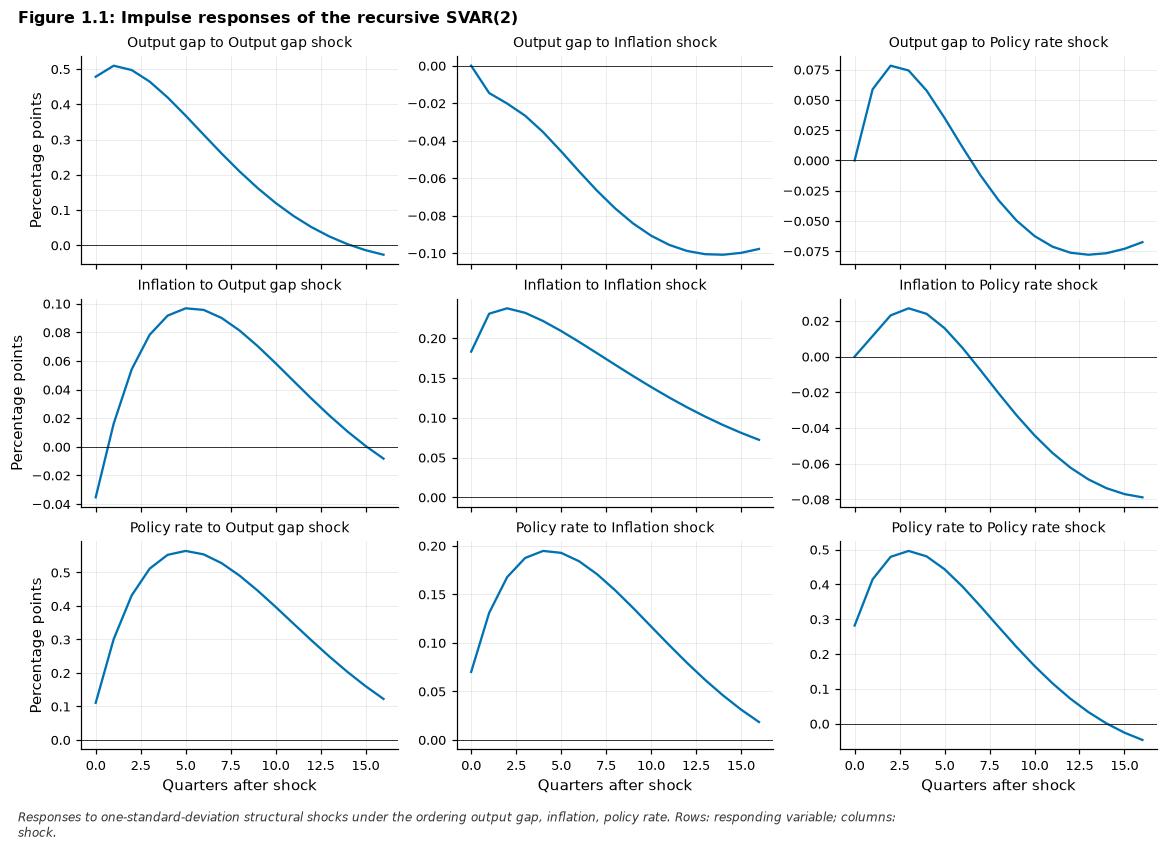

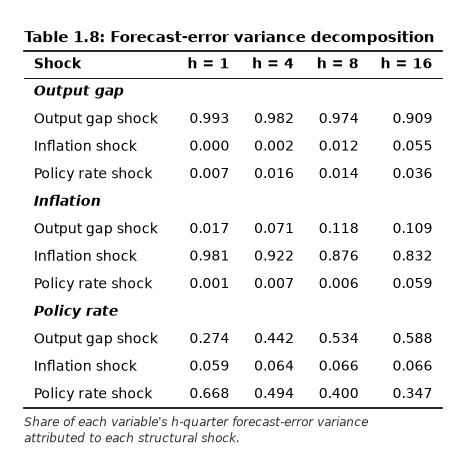

In [9]:
IRF_H = 16
fig = plots.irf_grid(svar.irf(horizon=IRF_H), NAMES, labels=SHORT)
nb.figure(
    fig,
    "impulse_responses",
    "Impulse responses of the recursive SVAR(2)",
    note=(
        "Responses to one-standard-deviation structural shocks under the ordering output gap,"
        " inflation, policy rate. Rows: responding variable; columns: shock."
    ),
)

fevd = svar.fevd(horizon=IRF_H)  # (horizon + 1, variable, shock); rows sum to one
fevd_table = pd.DataFrame({
    f"h = {k}": {
        (SHORT[v], f"{SHORT[s]} shock"): fevd[k, r, c]
        for r, v in enumerate(NAMES)
        for c, s in enumerate(NAMES)
    }
    for k in (1, 4, 8, IRF_H)
})
fevd_table.index = pd.MultiIndex.from_tuples(fevd_table.index, names=["Variable", "Shock"])
nb.table(
    fevd_table,
    "variance_decomposition",
    "Forecast-error variance decomposition",
    note=(
        "Share of each variable's h-quarter forecast-error variance attributed to each"
        " structural shock."
    ),
)

### Saving the economy

The restricted system is saved as a portable specification: the two coefficient vectors on the full
regressor set (dropped terms as zeros) and the residual standard deviations $\sqrt{SSR/(n-k)}$. The
policy-rule and reinforcement-learning notebooks load this file.

In [10]:
spec = svar_fit.to_spec(
    sample=f"{cfg.train_start}-{cfg.train_end}", vintage=panel.retrieved, alpha_drop=ALPHA_DROP
)
print(
    "Saved",
    spec.save(nb.artifacts("linear") / "svar_restricted.json").relative_to(nb.workspace.root),
)

Saved artifacts/linear/svar_restricted.json


## Out-of-sample comparison: fitted linear environment vs. realized data

We evaluate how the estimated linear environment tracks realized macroeconomic dynamics after the
training window. This is presented as a **descriptive out-of-sample comparison**, not a claim of
structural stability across policy regimes (Lütkepohl, 2005).

### Out-of-sample window
The out-of-sample period begins at **2007Q3** and extends to the most recent available quarter. This split
allows a clean separation between estimation and evaluation, highlighting performance during and after
the Global Financial Crisis and subsequent regime changes. The out-of-sample observations come from the
same FRED responses (fetched once over the full span) and the same `FredHelpers.to_pd_series`
standardization step, which guarantees comparability between training and evaluation samples (Federal
Reserve Bank of St. Louis, n.d.; Sunder, 2025).

### Forecast construction (design choice)
Forecasts are generated using the restricted estimated coefficients. Unless explicitly stated otherwise,
the notebook uses **realized lagged values** as inputs rather than recursively feeding forecasted values
back into the lag structure. This choice isolates one-step mapping performance from multi-step error
accumulation.

Because the inflation equation contains contemporaneous $y_t$ under the recursive ordering, its fitted
value is **conditional on realized $y_t$**. In reduced-form terms that equals the one-step forecast plus
$a^\pi_{y,0}\,(y_t - \hat y_t)$, which is the closed form of the Waggoner–Zha conditional forecast that
`cultivars.forecast.conditional_forecast` computes in general; at horizon one it is applied directly.

The unrestricted fixed-coefficient environment is carried alongside the restricted one throughout, so
that the effect of the paper's lag restriction on out-of-sample tracking can be read off directly.

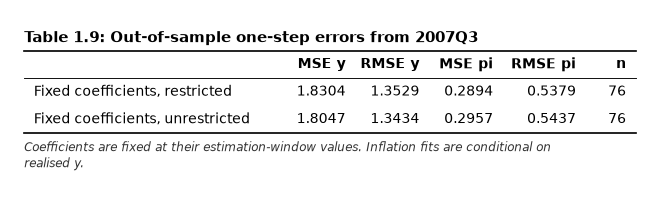

In [11]:
# Restricted environment: one-step fits on realised lags over training + out-of-sample
fixed = df_all.join(spec.predict(df_all))

# Unrestricted environment: cultivars reduced form + Cholesky (and the equivalent structural OLS)
unres = lin.one_step(var, svar, df_all, cfg.train_start)
fixed["y_hat_unres"], fixed["pi_hat_unres"] = unres["y_hat"], unres["pi_hat"]
_, X_y_all, _, X_pi_all = lin.structural_design(df_all)
assert np.allclose(unres.loc[X_y_all.index, "y_hat"], svar_fit.full_y.predict(X_y_all))
assert np.allclose(unres.loc[X_pi_all.index, "pi_hat"], svar_fit.full_pi.predict(X_pi_all))

oos_fixed = fixed.loc[cfg.oos_start :]
assert not oos_fixed.isna().any().any()
af.save_frame(fixed, nb.artifacts("linear") / "one_step_fixed.csv")

oos_metrics = pd.DataFrame({
    "Fixed coefficients, restricted": lin.error_metrics(oos_fixed),
    "Fixed coefficients, unrestricted": lin.error_metrics(
        oos_fixed, "y_hat_unres", "pi_hat_unres"
    ),
}).T
oos_metrics["n"] = oos_metrics["n"].astype(int)
nb.table(
    oos_metrics,
    "oos_error_metrics",
    f"Out-of-sample one-step errors from {cfg.oos_start}",
    float_format="{:.4f}",
    note=(
        "Coefficients are fixed at their estimation-window values. Inflation fits are"
        " conditional on realised y."
    ),
)

### Out-of-sample tracking: output gap and inflation
The figures compare realized $y_t$ and $\pi_t$ (2007Q3 onward) to the one-step fitted values of the
restricted environment; the unrestricted environment is shown as a thin dotted line for reference.

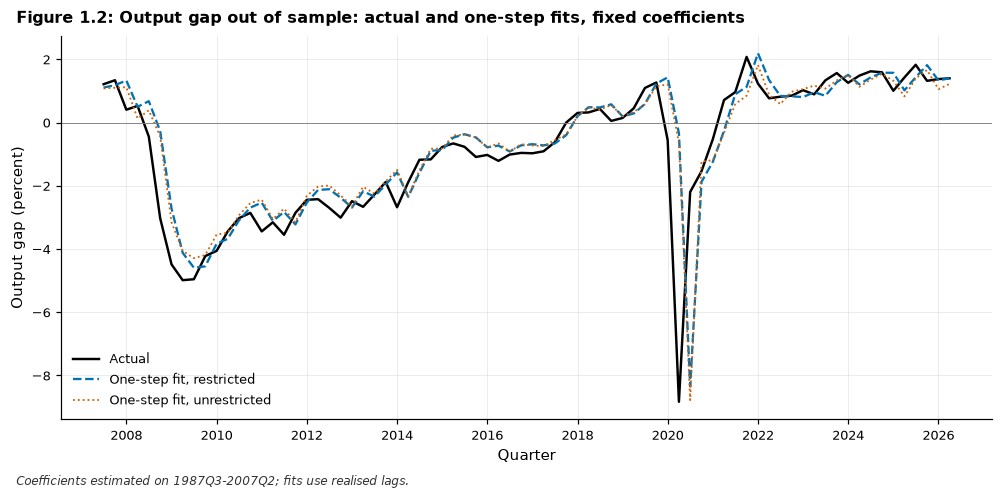

In [12]:
fig = plots.actual_vs_fit(
    oos_fixed,
    "y",
    {"One-step fit, restricted": "y_hat", "One-step fit, unrestricted": "y_hat_unres"},
)
nb.figure(
    fig,
    "oos_output_gap",
    "Output gap out of sample: actual and one-step fits, fixed coefficients",
    note=(
        f"Coefficients estimated on {cfg.train_start}-{cfg.train_end}; fits use realised lags."
    ),
)

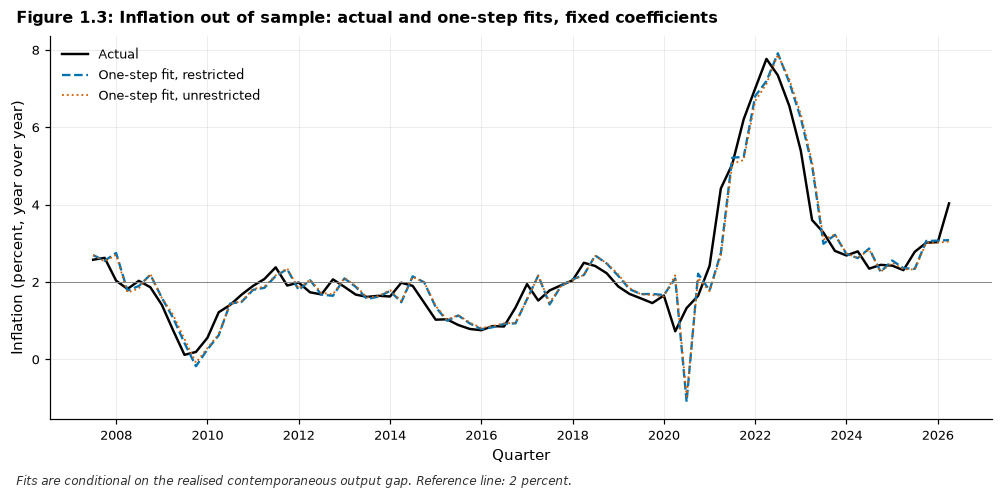

In [13]:
fig = plots.actual_vs_fit(
    oos_fixed,
    "pi",
    {"One-step fit, restricted": "pi_hat", "One-step fit, unrestricted": "pi_hat_unres"},
)
nb.figure(
    fig,
    "oos_inflation",
    "Inflation out of sample: actual and one-step fits, fixed coefficients",
    note=(
        "Fits are conditional on the realised contemporaneous output gap. Reference line: 2"
        " percent."
    ),
)

## In-sample fit and error diagnostics

To benchmark the linear environment on the estimation sample, we compute fitted values and squared errors
for both equations. These diagnostics indicate whether the restricted SVAR captures the primary short-run
dynamics within the training window (Lütkepohl, 2005).

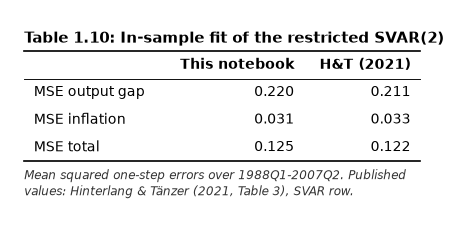

In [14]:
in_sample = fixed.loc[: cfg.train_end].dropna(subset=["y_hat", "pi_hat"]).copy()
in_sample["se_y"] = (in_sample["y"] - in_sample["y_hat"]) ** 2
in_sample["se_pi"] = (in_sample["pi"] - in_sample["pi_hat"]) ** 2

fit_table = pd.DataFrame({
    "This notebook": {
        "MSE output gap": in_sample["se_y"].mean(),
        "MSE inflation": in_sample["se_pi"].mean(),
        "MSE total": 0.5 * (in_sample["se_y"].mean() + in_sample["se_pi"].mean()),
    },
    "H&T (2021)": {"MSE output gap": 0.211, "MSE inflation": 0.033, "MSE total": 0.122},
})
nb.table(
    fit_table,
    "in_sample_fit",
    "In-sample fit of the restricted SVAR(2)",
    note=(
        f"Mean squared one-step errors over {in_sample.index[0]}-{in_sample.index[-1]}. "
        "Published values: Hinterlang & Tänzer (2021, Table 3), SVAR row."
    ),
)

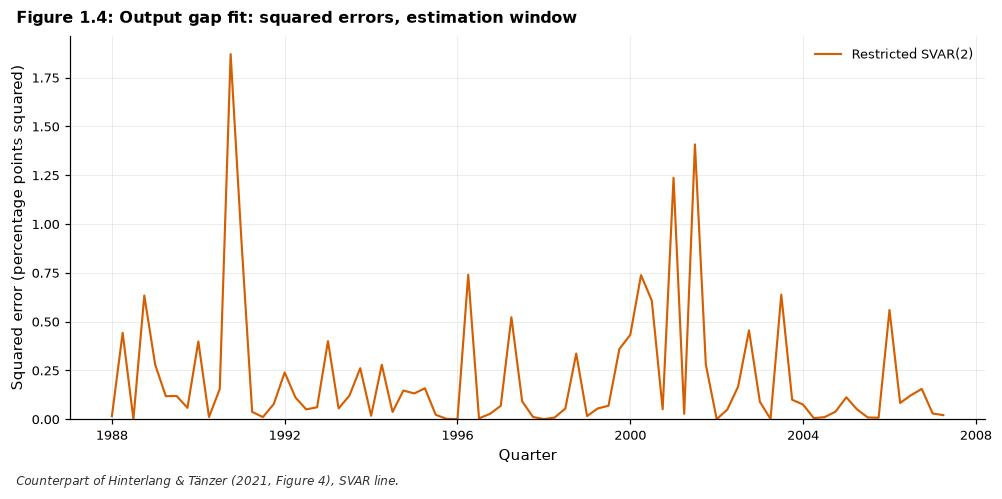

In [15]:
fig = plots.squared_errors({"Restricted SVAR(2)": in_sample["se_y"]})
nb.figure(
    fig,
    "in_sample_se_output_gap",
    "Output gap fit: squared errors, estimation window",
    note="Counterpart of Hinterlang & Tänzer (2021, Figure 4), SVAR line.",
)

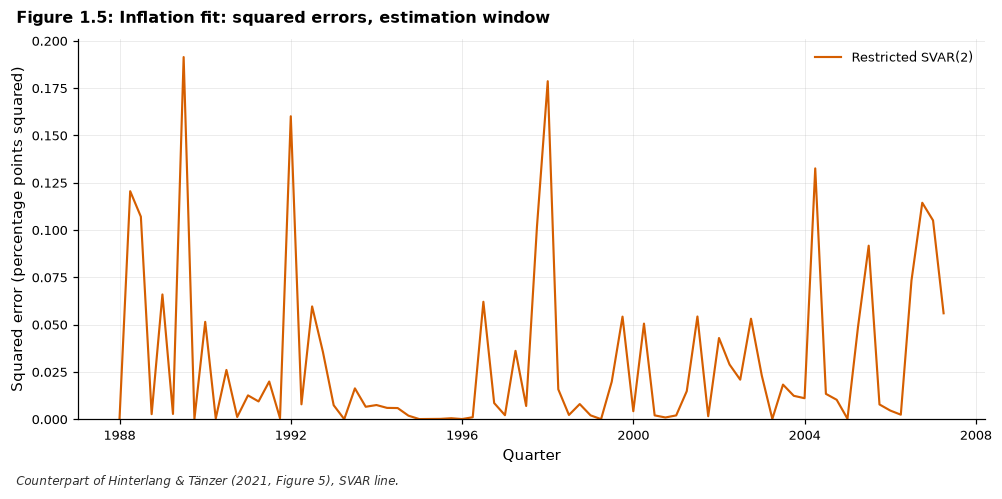

In [16]:
fig = plots.squared_errors({"Restricted SVAR(2)": in_sample["se_pi"]})
nb.figure(
    fig,
    "in_sample_se_inflation",
    "Inflation fit: squared errors, estimation window",
    note="Counterpart of Hinterlang & Tänzer (2021, Figure 5), SVAR line.",
)

Note: The y-axis scale is different from the paper due to our model using the correct units (YoY
percent, not decimals). In addition, the smaller squared errors reflect a tighter fit in the replication
relative to the Bundesbank baseline.

# References (APA)

## Software

1. Sunder, N. (2026). cultivars: Research-grade time series econometrics for Python (v1.0.0a1). https://pypi.org/project/cultivars/
2. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (v3.0.0). Zenodo. https://doi.org/10.5281/zenodo.17635942
3. The pandas development team. (2026). pandas-dev/pandas: Pandas. Zenodo. https://doi.org/10.5281/zenodo.18675244
4. Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2
5. Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., … SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. https://doi.org/10.1038/s41592-019-0686-2
6. The Matplotlib Development Team. (2025). Matplotlib: Visualization with Python. Zenodo. https://doi.org/10.5281/zenodo.17595503
7. Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. In *Proceedings of the 9th Python in Science Conference* (pp. 92–96). https://doi.org/10.25080/Majora-92bf1922-011
8. Kluyver, T., Ragan-Kelley, B., Pérez, F., Granger, B., Bussonnier, M., Frederic, J., Kelley, K., Hamrick, J., Grout, J., Corlay, S., Ivanov, P., Avila, D., Abdalla, S., Willing, C., & Jupyter Development Team. (2016). Jupyter Notebooks – a publishing format for reproducible computational workflows. In *Positioning and Power in Academic Publishing: Players, Agents and Agendas* (pp. 87–90). IOS Press. https://doi.org/10.3233/978-1-61499-649-1-87
9. Python Software Foundation. (2025). Python (Version 3.13) [Computer software]. https://www.python.org/

## Papers & Books

1. Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. *SSRN*. https://doi.org/10.2139/ssrn.4013384
2. Sims, C. A. (1980). Macroeconomics and reality. *Econometrica*, 48(1), 1–48. https://doi.org/10.2307/1912017
3. Lütkepohl, H. (2005). *New introduction to multiple time series analysis*. Springer. https://doi.org/10.1007/3-540-27752-8
4. Clements, M. P., & Hendry, D. F. (1998). *Forecasting economic time series*. Cambridge University Press. https://doi.org/10.1017/CBO9780511599286
5. Stock, J. H., & Watson, M. W. (2007). Why has U.S. inflation become harder to forecast? *Journal of Money, Credit and Banking*, 39(s1), 3–33. https://doi.org/10.1111/j.1538-4616.2007.00014.x
6. Cogley, T., & Sargent, T. J. (2005). Drifts and volatilities: Monetary policies and outcomes in the post WWII US. *Review of Economic Dynamics*, 8(2), 262–302. https://doi.org/10.1016/j.red.2004.10.009
7. Primiceri, G. E. (2005). Time varying structural vector autoregressions and monetary policy. *Review of Economic Studies*, 72(3), 821–852. https://doi.org/10.1111/j.1467-937X.2005.00353.x
8. Hamilton, J. D. (1994). *Time series analysis*. Princeton University Press.
9. Giacomini, R., & White, H. (2006). Tests of conditional predictive ability. *Econometrica*, 74(6), 1545–1578. https://doi.org/10.1111/j.1468-0262.2006.00718.x
10. Carter, C. K., & Kohn, R. (1994). On Gibbs sampling for state space models. *Biometrika*, 81(3), 541–553. https://doi.org/10.1093/biomet/81.3.541
11. Kim, S., Shephard, N., & Chib, S. (1998). Stochastic volatility: Likelihood inference and comparison with ARCH models. *Review of Economic Studies*, 65(3), 361–393. https://doi.org/10.1111/1467-937X.00050
12. Kim, C.-J., & Nelson, C. R. (1999). *State-space models with regime switching: Classical and Gibbs-sampling approaches with applications*. MIT Press.
13. Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics*, 13(3), 253–263. https://doi.org/10.1080/07350015.1995.10524599
14. Harvey, D., Leybourne, S., & Newbold, P. (1997). Testing the equality of prediction mean squared errors. *International Journal of Forecasting*, 13(2), 281–291. https://doi.org/10.1016/S0169-2070(96)00719-4
15. Hansen, P. R., Lunde, A., & Nason, J. M. (2011). The model confidence set. *Econometrica*, 79(2), 453–497. https://doi.org/10.3982/ECTA5771
16. Mincer, J., & Zarnowitz, V. (1969). The evaluation of economic forecasts. In J. Mincer (Ed.), *Economic forecasts and expectations: Analysis of forecasting behavior and performance* (pp. 3–46). NBER.
17. Waggoner, D. F., & Zha, T. (1999). Conditional forecasts in dynamic multivariate models. *Review of Economics and Statistics*, 81(4), 639–651. https://doi.org/10.1162/003465399558508
18. Federal Reserve Bank of St. Louis. (n.d.). *Federal Reserve Economic Data (FRED)*. https://fred.stlouisfed.org/

# Export

The last cell converts this notebook to PDF in the shared `documents/` directory. A kernel can only
convert the copy saved on disk, so the cell waits briefly for the editor to save; if the file is still
behind, it writes nothing and asks you to save and run it again.

In [17]:
nb.export_pdf()

/var/folders/cj/p5jdwnb923752l7zjc_69j5w0000gn/T/ipykernel_85645/281924391.py:1: UserWarning: 01_linear_svar.ipynb on disk does not yet contain this run's outputs, so no PDF was written. Save the notebook and run this cell again.
  nb.export_pdf()
